# 🍽️ Exploratory Data Analysis — Zomato Bangalore Restaurants

**Dataset:** [Zomato Bangalore Restaurants — Kaggle](https://www.kaggle.com/datasets/himanshupoddar/zomato-bangalore-restaurants)  
**Author:** ADITI CHAUDHARY  
**Date:** April 2026  

---

## 📌 Project Overview

Zomato is one of India's largest food-tech platforms, operating in hundreds of cities. This notebook performs a **deep Exploratory Data Analysis (EDA)** on restaurant data from **Bangalore**, India's tech capital and food hub.

### 🎯 Objectives
- Understand the structure and quality of the dataset
- Clean and preprocess the data for analysis
- Uncover meaningful insights about Bangalore's restaurant ecosystem
- Visualize trends using professional-grade charts

### 🔑 Key Questions We'll Answer
1. Which restaurant types and cuisines dominate Bangalore?
2. How does cost relate to ratings across different localities?
3. Which locations have the highest concentration of top-rated restaurants?
4. Does online ordering availability impact customer ratings?
5. What are the most popular cuisine combinations?

---
## 1️⃣ Import Libraries

We start by importing all necessary libraries:
- **pandas** — data manipulation and analysis
- **numpy** — numerical operations
- **matplotlib** — base plotting library
- **seaborn** — statistical data visualization built on matplotlib
- **warnings** — suppress unnecessary warnings for a clean output

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ── Plot aesthetics ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': '#F9F5F0',
    'axes.facecolor': '#F9F5F0',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans',
})

PALETTE = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A', '#F4A261', '#264653']
sns.set_palette(PALETTE)

print("✅ All libraries imported successfully.")
print(f"   pandas  {pd.__version__}")
print(f"   numpy   {np.__version__}")
print(f"   seaborn {sns.__version__}")

✅ All libraries imported successfully.
   pandas  2.3.3
   numpy   2.4.4
   seaborn 0.13.2


---
## 2️⃣ Data Loading

We load the dataset using `pd.read_csv()`. The file is assumed to be downloaded from Kaggle and placed in the working directory.

> 📂 **Source:** `zomato.csv` — Zomato Bangalore Restaurants dataset

In [2]:
df = pd.read_csv('zomato.csv')

print(f"📊 Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("\n🔍 First 5 rows:")
df.head()

📊 Dataset Shape: 51,717 rows × 17 columns

🔍 First 5 rows:


,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [3]:
print("📋 Column names and data types:")
df.dtypes

📋 Column names and data types:


url                            object
address                        object
name                           object
online_order                   object
book_table                     object
rate                           object
votes                           int64
phone                          object
location                       object
rest_type                      object
dish_liked                     object
cuisines                       object
approx_cost(for two people)    object
reviews_list                   object
menu_item                      object
listed_in(type)                object
listed_in(city)                object
dtype: object

In [4]:
print("❓ Missing values per column:")
df.isnull().sum().sort_values(ascending=False)

❓ Missing values per column:


dish_liked                     28078
rate                            7775
phone                           1208
approx_cost(for two people)      346
rest_type                        227
cuisines                          45
location                          21
url                                0
address                            0
votes                              0
name                               0
online_order                       0
book_table                         0
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

---
## 3️⃣ Data Cleaning

Raw data is rarely analysis-ready. This section addresses:
- **Duplicate rows** — removing exact copies
- **Missing values** — dropping or imputing where appropriate
- **Data type fixes** — converting strings to numeric
- **Column renaming** — for clarity and consistency
- **Noise removal** — stripping special characters from numeric-like columns

### 3.1 Rename Columns
Standardise column names to `snake_case` for easy access.

In [5]:
df.rename(columns={
    'approx_cost(for two people)': 'cost_for_two',
    'listed_in(type)': 'listed_type',
    'listed_in(city)': 'listed_city',
}, inplace=True)

print("✅ Columns renamed.")
print(df.columns.tolist())

✅ Columns renamed.
['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'cost_for_two', 'reviews_list', 'menu_item', 'listed_type', 'listed_city']


### 3.2 Remove Duplicates
Duplicate entries skew aggregations and inflate counts.

In [6]:
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)
print(f"🗑️  Removed {before - after:,} duplicate rows. ({before:,} → {after:,})")

🗑️  Removed 0 duplicate rows. (51,717 → 51,717)


### 3.3 Clean the `rate` Column
The `rate` column contains values like `"4.1/5"` and `"NEW"`. We strip the `"/5"` suffix and cast to float.

In [7]:
df['rate'] = df['rate'].astype(str).str.replace('/5', '', regex=False).str.strip()
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

print(f"✅ Rate column cleaned. Unique NaN count: {df['rate'].isna().sum():,}")
df['rate'].describe()

✅ Rate column cleaned. Unique NaN count: 10,052


count    41665.000000
mean         3.700449
std          0.440513
min          1.800000
25%          3.400000
50%          3.700000
75%          4.000000
max          4.900000
Name: rate, dtype: float64

### 3.4 Clean the `cost_for_two` Column
This column has commas (e.g., `"1,200"`). We remove them and cast to numeric.

In [8]:
df['cost_for_two'] = df['cost_for_two'].astype(str).str.replace(',', '', regex=False)
df['cost_for_two'] = pd.to_numeric(df['cost_for_two'], errors='coerce')

print(f"✅ cost_for_two cleaned. NaN count: {df['cost_for_two'].isna().sum():,}")
df['cost_for_two'].describe()

✅ cost_for_two cleaned. NaN count: 346


count    51371.000000
mean       555.431566
std        438.850728
min         40.000000
25%        300.000000
50%        400.000000
75%        650.000000
max       6000.000000
Name: cost_for_two, dtype: float64

### 3.5 Handle Missing Values

**Strategy:**
- Drop rows where **`rate`** is missing — it's our primary analysis metric
- Fill missing **`cost_for_two`** with the median (robust to outliers)
- Fill missing **`cuisines`** with `'Unknown'`
- Drop rows with missing **`location`** (very few, not imputable)

In [9]:
df.dropna(subset=['rate'], inplace=True)
df['cost_for_two'].fillna(df['cost_for_two'].median(), inplace=True)
df['cuisines'].fillna('Unknown', inplace=True)
df.dropna(subset=['location'], inplace=True)

print(f"✅ Missing values handled. Final shape: {df.shape}")
print("\n📉 Remaining nulls:")
df.isnull().sum()[df.isnull().sum() > 0]

✅ Missing values handled. Final shape: (41665, 17)

📉 Remaining nulls:


phone           814
rest_type       149
dish_liked    18203
dtype: int64

### 3.6 Fix Data Types

In [10]:
bool_map = {'Yes': True, 'No': False}
df['online_order'] = df['online_order'].map(bool_map)
df['book_table']   = df['book_table'].map(bool_map)

print("✅ Boolean columns converted.")
df[['online_order', 'book_table']].value_counts()

✅ Boolean columns converted.


online_order  book_table
True          False         23452
False         False         11909
True          True           3754
False         True           2550
Name: count, dtype: int64

### 3.7 Summary After Cleaning

In [11]:
print("=" * 50)
print("📦 CLEAN DATASET SUMMARY")
print("=" * 50)
print(f"  Rows        : {df.shape[0]:,}")
print(f"  Columns     : {df.shape[1]}")
print(f"  Restaurants : {df['name'].nunique():,} unique")
print(f"  Locations   : {df['location'].nunique()} unique")
print(f"  Avg Rating  : {df['rate'].mean():.2f} / 5")
print(f"  Avg Cost(2) : ₹{df['cost_for_two'].mean():.0f}")
print("=" * 50)

📦 CLEAN DATASET SUMMARY
  Rows        : 41,665
  Columns     : 17
  Restaurants : 6,649 unique
  Locations   : 92 unique
  Avg Rating  : 3.70 / 5
  Avg Cost(2) : ₹603


---
## 4️⃣ Exploratory Data Analysis (EDA)

Now that the data is clean, we explore it systematically — from summary statistics to grouped insights.

### 4.1 Summary Statistics

In [12]:
df[['rate', 'votes', 'cost_for_two']].describe().round(2)

,rate,votes,cost_for_two
count,41665.00,41665.00,41665.00
mean,3.70,351.65,602.66
std,0.44,881.80,463.02
min,1.80,0.00,40.00
25%,3.40,21.00,300.00
50%,3.70,73.00,500.00
75%,4.00,276.00,700.00
max,4.90,16832.00,6000.00


### 4.2 💡 Insight 1 — Online Ordering Impact on Ratings

> **Question:** Do restaurants that accept online orders tend to receive higher ratings?

This is a critical business question — if online ordering correlates with better ratings, it may reflect better customer reach and service.

In [13]:
insight1 = df.groupby('online_order')['rate'].agg(['mean', 'median', 'count'])
insight1.index = ['No Online Order', 'Accepts Online Order']
insight1.columns = ['Mean Rating', 'Median Rating', 'Count']
insight1 = insight1.round(3)

print("📊 Insight 1: Online Order vs Rating")
print(insight1)
diff = insight1.loc['Accepts Online Order', 'Mean Rating'] - insight1.loc['No Online Order', 'Mean Rating']
print(f"\n🔍 Restaurants WITH online ordering score {diff:+.3f} points higher on average.")

📊 Insight 1: Online Order vs Rating
                      Mean Rating  Median Rating  Count
No Online Order             3.659            3.7  14459
Accepts Online Order        3.722            3.8  27206

🔍 Restaurants WITH online ordering score +0.063 points higher on average.


### 4.3 💡 Insight 2 — Top Locations by Average Rating

> **Question:** Which Bangalore localities consistently produce the highest-rated dining experiences?

We filter to locations with at least **50 restaurants** to avoid small-sample bias.

In [14]:
location_stats = (
    df.groupby('location')
    .agg(avg_rating=('rate', 'mean'), restaurant_count=('name', 'count'), avg_cost=('cost_for_two', 'mean'))
    .query('restaurant_count >= 50')
    .sort_values('avg_rating', ascending=False)
    .round(2)
)

print("📊 Insight 2: Top 10 Locations by Avg Rating (min 50 restaurants)")
location_stats.head(10)

📊 Insight 2: Top 10 Locations by Avg Rating (min 50 restaurants)


,avg_rating,restaurant_count,avg_cost
location,,,
Lavelle Road,4.14,487,1354.72
Koramangala 3rd Block,4.02,191,834.82
St. Marks Road,4.02,343,883.67
Koramangala 5th Block,4.01,2319,679.00
Church Street,3.99,546,839.84
Koramangala 4th Block,3.92,841,758.32
Cunningham Road,3.90,475,867.16
Residency Road,3.86,605,1029.17
MG Road,3.86,811,1227.99


### 4.4 💡 Insight 3 — Cost vs Rating Segment Analysis

> **Question:** Are expensive restaurants necessarily better rated?

We segment restaurants into budget tiers and compare average ratings across segments.

In [15]:
bins   = [0, 300, 600, 1000, 2000, 10000]
labels = ['Budget\n(<₹300)', 'Affordable\n(₹300–600)', 'Mid-Range\n(₹600–1k)', 'Premium\n(₹1k–2k)', 'Luxury\n(₹2k+)']

df['cost_segment'] = pd.cut(df['cost_for_two'], bins=bins, labels=labels)

segment_stats = df.groupby('cost_segment', observed=False).agg(
    avg_rating=('rate', 'mean'),
    count=('name', 'count')
).round(3)

print("📊 Insight 3: Rating by Cost Segment")
segment_stats

📊 Insight 3: Rating by Cost Segment


,avg_rating,count
cost_segment,,
Budget\n(<₹300),3.567,12587
Affordable\n(₹300–600),3.618,16153
Mid-Range\n(₹600–1k),3.804,7790
Premium\n(₹1k–2k),4.130,4518
Luxury\n(₹2k+),4.124,617


### 4.5 💡 Insight 4 — Most Popular Cuisines

In [16]:
cuisine_series = df['cuisines'].str.split(',').explode().str.strip()
top_cuisines   = cuisine_series.value_counts().head(15)

print("📊 Insight 4: Top 15 Cuisines by Frequency")
print(top_cuisines.to_string())

📊 Insight 4: Top 15 Cuisines by Frequency
cuisines
North Indian    17406
Chinese         13005
South Indian     6394
Fast Food        6360
Continental      5245
Biryani          5071
Cafe             4828
Desserts         4537
Beverages        3873
Italian          3213
Street Food      2233
Bakery           2029
Pizza            1900
Burger           1869
Seafood          1662


### 4.6 💡 Insight 5 — Restaurant Type Distribution & Ratings

In [17]:
type_stats = (
    df.groupby('rest_type')
    .agg(avg_rating=('rate','mean'), count=('name','count'))
    .query('count >= 100')
    .sort_values('avg_rating', ascending=False)
    .round(2)
)

print("📊 Insight 5: Restaurant Types (min 100) by Rating")
type_stats

📊 Insight 5: Restaurant Types (min 100) by Rating


,avg_rating,count
rest_type,,
"Microbrewery, Casual Dining",4.37,121
"Casual Dining, Cafe",4.19,318
"Casual Dining, Pub",4.18,127
Fine Dining,4.15,343
"Cafe, Dessert Parlor",4.15,144
"Dessert Parlor, Cafe",4.14,144
"Bar, Casual Dining",4.13,395
"Pub, Casual Dining",4.09,236
"Casual Dining, Bar",4.08,1110


---
## 5️⃣ Data Visualization

The following section presents **6 professional visualizations** that tell a cohesive data story about Bangalore's restaurant scene.

### 📊 Plot 1 — Bar Plot: Top 10 Most Common Restaurant Types

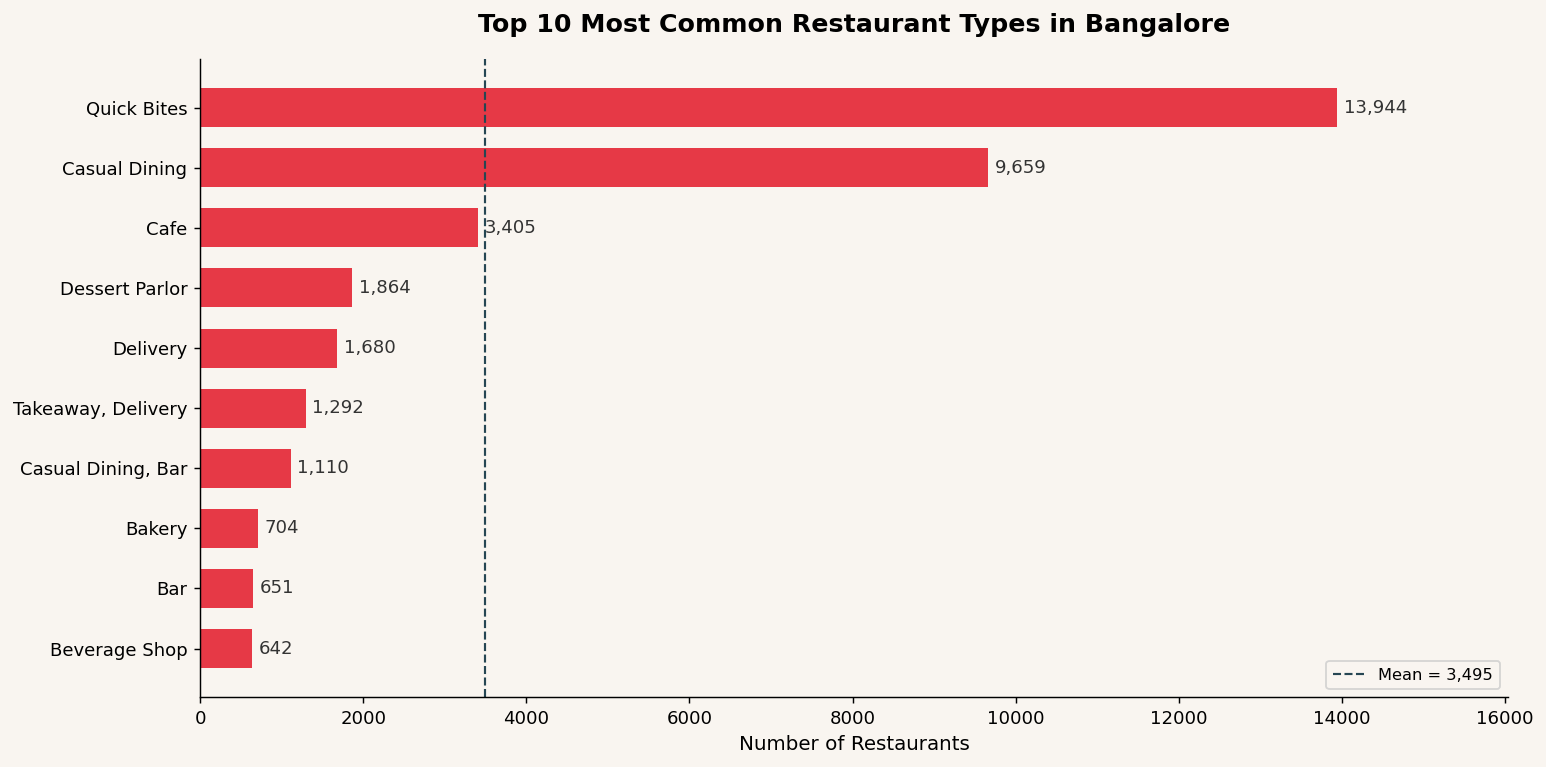

💡 Quick Delivery and Casual Dining dominate Bangalore's restaurant landscape.


In [18]:
top_types = df['rest_type'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_types.index[::-1], top_types.values[::-1],
               color=PALETTE[0], edgecolor='none', height=0.65)

# Annotate
for bar in bars:
    ax.text(bar.get_width() + 80, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():,.0f}', va='center', fontsize=10, color='#333')

ax.set_title('Top 10 Most Common Restaurant Types in Bangalore', pad=15)
ax.set_xlabel('Number of Restaurants')
ax.set_xlim(0, top_types.max() * 1.15)
ax.axvline(top_types.mean(), color='#264653', linestyle='--', linewidth=1.2, label=f'Mean = {top_types.mean():,.0f}')
ax.legend(fontsize=9)
fig.tight_layout()
plt.savefig('plot1_restaurant_types.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Quick Delivery and Casual Dining dominate Bangalore's restaurant landscape.")

### 📊 Plot 2 — Count Plot: Online Order Availability by Restaurant Type

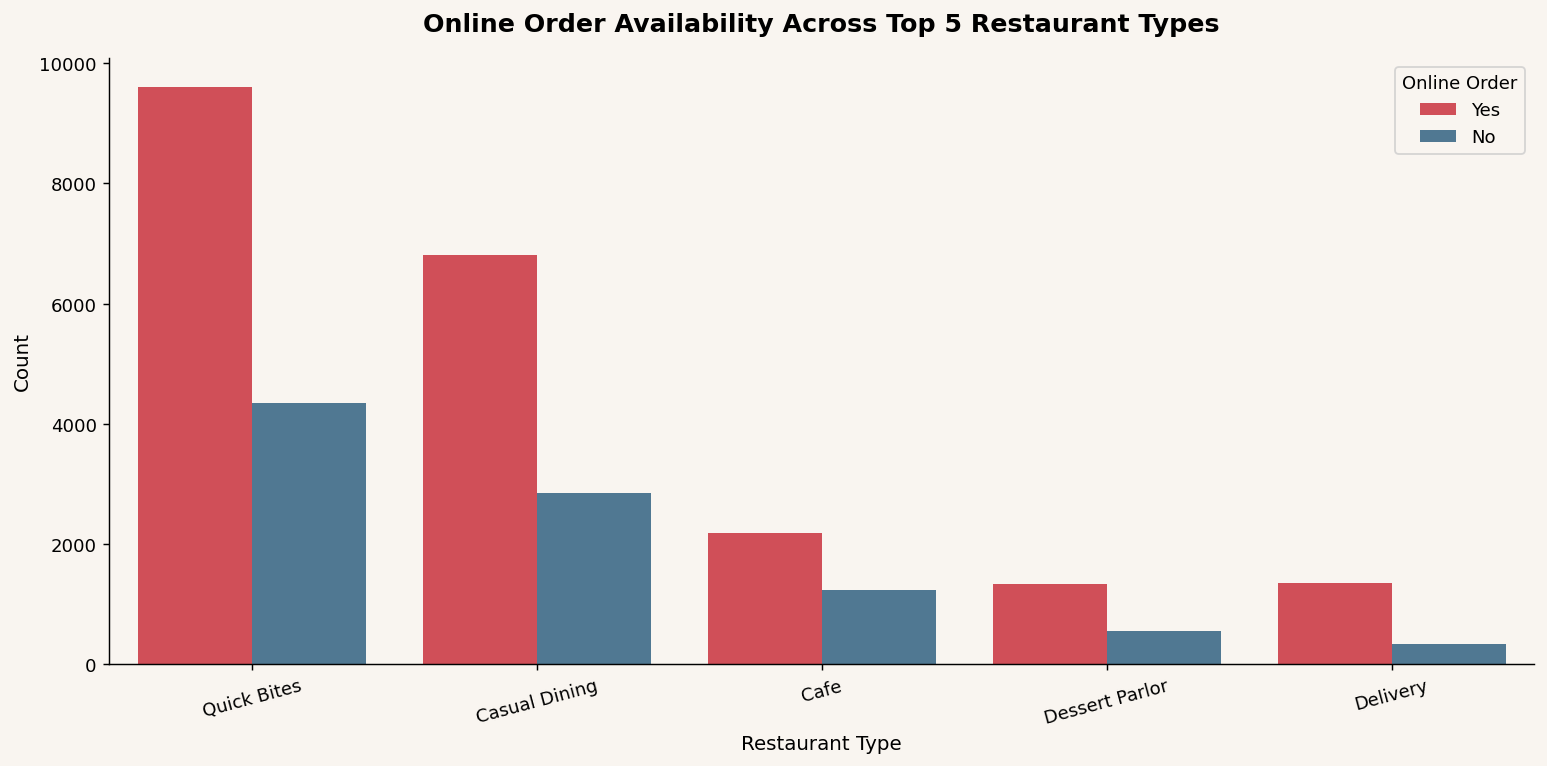

💡 Quick Bites overwhelmingly offer online ordering, while Casual Dining is more split.


In [19]:
top5_types = df['rest_type'].value_counts().head(5).index
df_top5 = df[df['rest_type'].isin(top5_types)].copy()
df_top5['Online Order'] = df_top5['online_order'].map({True: 'Yes', False: 'No'})

fig, ax = plt.subplots(figsize=(12, 6))
sns.countplot(data=df_top5, x='rest_type', hue='Online Order',
              palette=[PALETTE[0], PALETTE[1]], ax=ax, edgecolor='none',
              order=top5_types)

ax.set_title('Online Order Availability Across Top 5 Restaurant Types', pad=15)
ax.set_xlabel('Restaurant Type')
ax.set_ylabel('Count')
ax.legend(title='Online Order', title_fontsize=10)
ax.tick_params(axis='x', rotation=15)
fig.tight_layout()
plt.savefig('plot2_online_order_countplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Quick Bites overwhelmingly offer online ordering, while Casual Dining is more split.")

### 📊 Plot 3 — Box Plot: Rating Distribution by Cost Segment

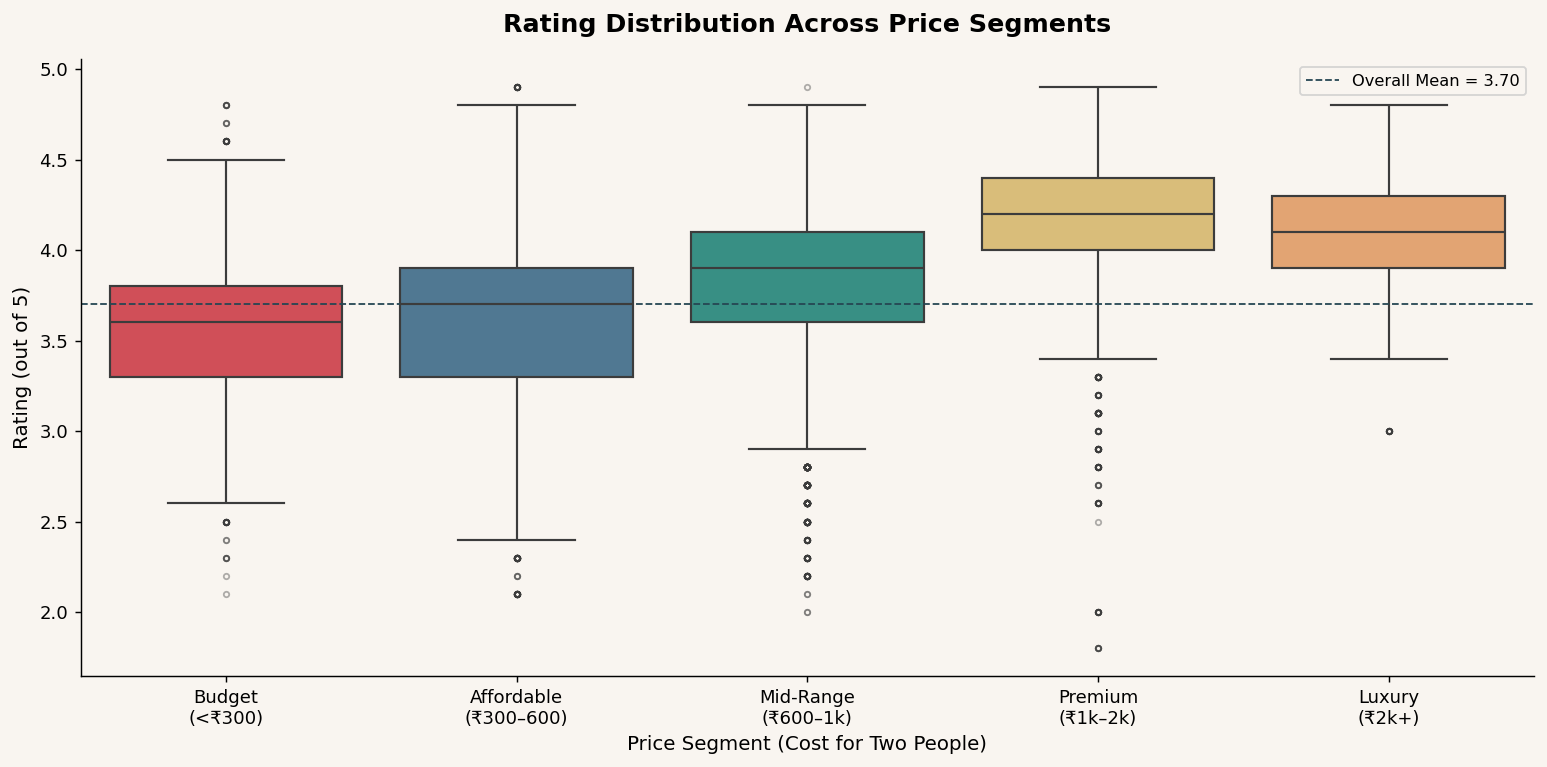

💡 Higher-priced restaurants tend to have higher median ratings, but with more variance.


In [20]:
df_seg = df.dropna(subset=['cost_segment'])

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_seg, x='cost_segment', y='rate',
            palette=PALETTE, ax=ax, linewidth=1.2,
            order=labels, flierprops=dict(marker='o', markersize=3, alpha=0.4))

ax.set_title('Rating Distribution Across Price Segments', pad=15)
ax.set_xlabel('Price Segment (Cost for Two People)')
ax.set_ylabel('Rating (out of 5)')
ax.axhline(df['rate'].mean(), linestyle='--', color='#264653', linewidth=1,
           label=f'Overall Mean = {df["rate"].mean():.2f}')
ax.legend(fontsize=9)
fig.tight_layout()
plt.savefig('plot3_rating_by_cost.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Higher-priced restaurants tend to have higher median ratings, but with more variance.")

### 📊 Plot 4 — Heatmap: Correlation Between Numerical Features

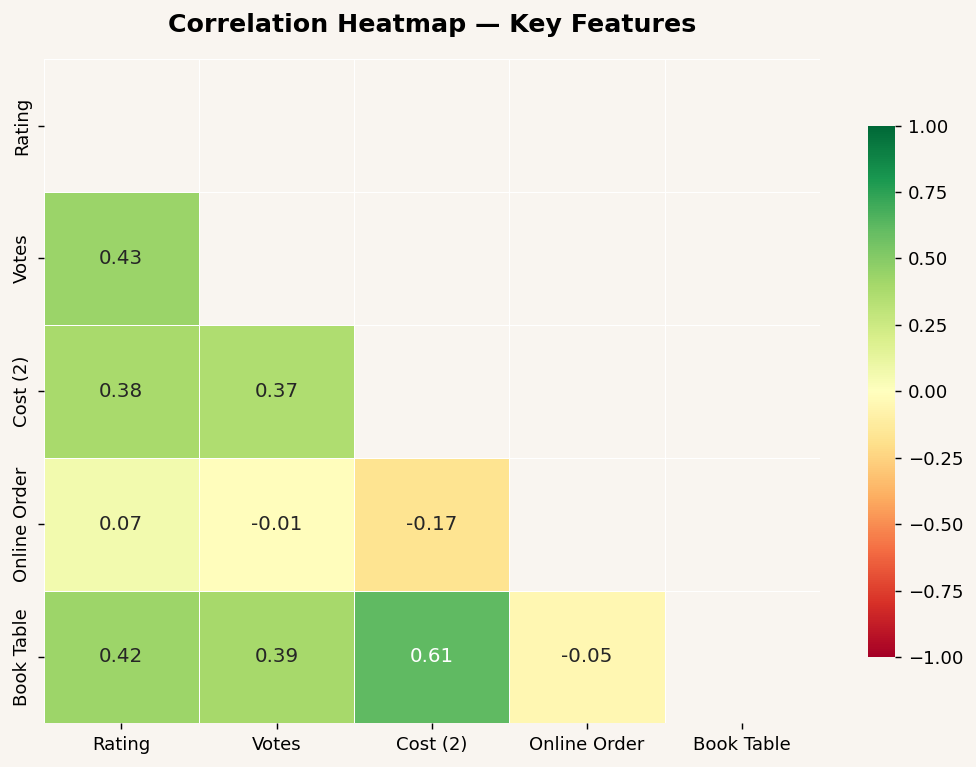

💡 Cost & Rating show moderate positive correlation. Votes correlate with online ordering presence.


In [21]:
num_df = df[['rate', 'votes', 'cost_for_two', 'online_order', 'book_table']].copy()
num_df['online_order'] = num_df['online_order'].astype(int)
num_df['book_table']   = num_df['book_table'].astype(int)
num_df.rename(columns={'online_order': 'Online Order', 'book_table': 'Book Table',
                        'rate': 'Rating', 'votes': 'Votes', 'cost_for_two': 'Cost (2)'}, inplace=True)

corr = num_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, linecolor='white', ax=ax,
            annot_kws={'size': 11}, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8})

ax.set_title('Correlation Heatmap — Key Features', pad=15)
fig.tight_layout()
plt.savefig('plot4_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Cost & Rating show moderate positive correlation. Votes correlate with online ordering presence.")

### 📊 Plot 5 — Horizontal Bar: Top 10 Cuisines by Count

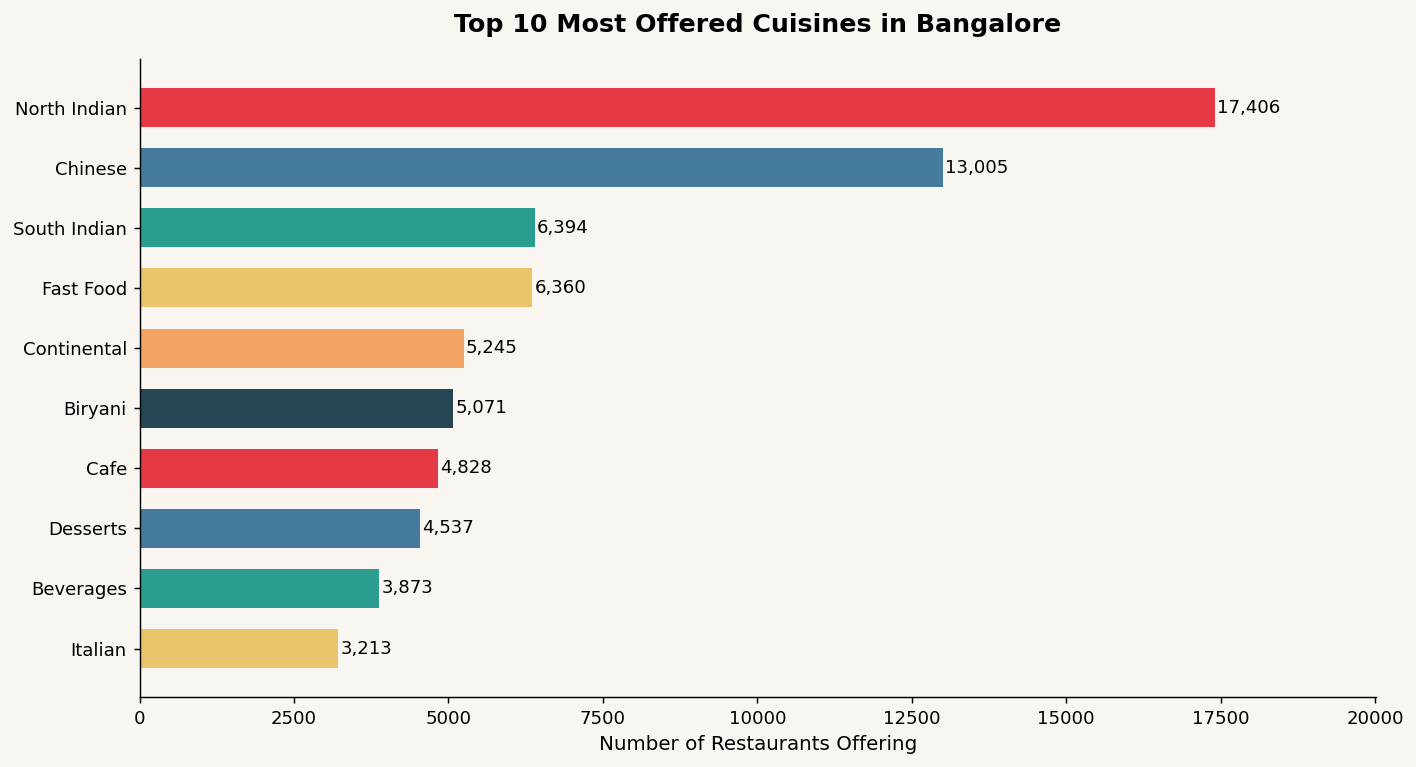

💡 North Indian and Chinese cuisines are the most widely offered — reflecting broad Indian appetite.


In [22]:
top10_c = cuisine_series.value_counts().head(10)

fig, ax = plt.subplots(figsize=(11, 6))
colors = [PALETTE[i % len(PALETTE)] for i in range(len(top10_c))]
bars = ax.barh(top10_c.index[::-1], top10_c.values[::-1],
               color=colors[::-1], edgecolor='none', height=0.65)

for bar in bars:
    ax.text(bar.get_width() + 40, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():,}', va='center', fontsize=10)

ax.set_title('Top 10 Most Offered Cuisines in Bangalore', pad=15)
ax.set_xlabel('Number of Restaurants Offering')
ax.set_xlim(0, top10_c.max() * 1.15)
fig.tight_layout()
plt.savefig('plot5_top_cuisines.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 North Indian and Chinese cuisines are the most widely offered — reflecting broad Indian appetite.")

### 📊 Plot 6 — Line Plot: Average Rating Trend Across Location Rank

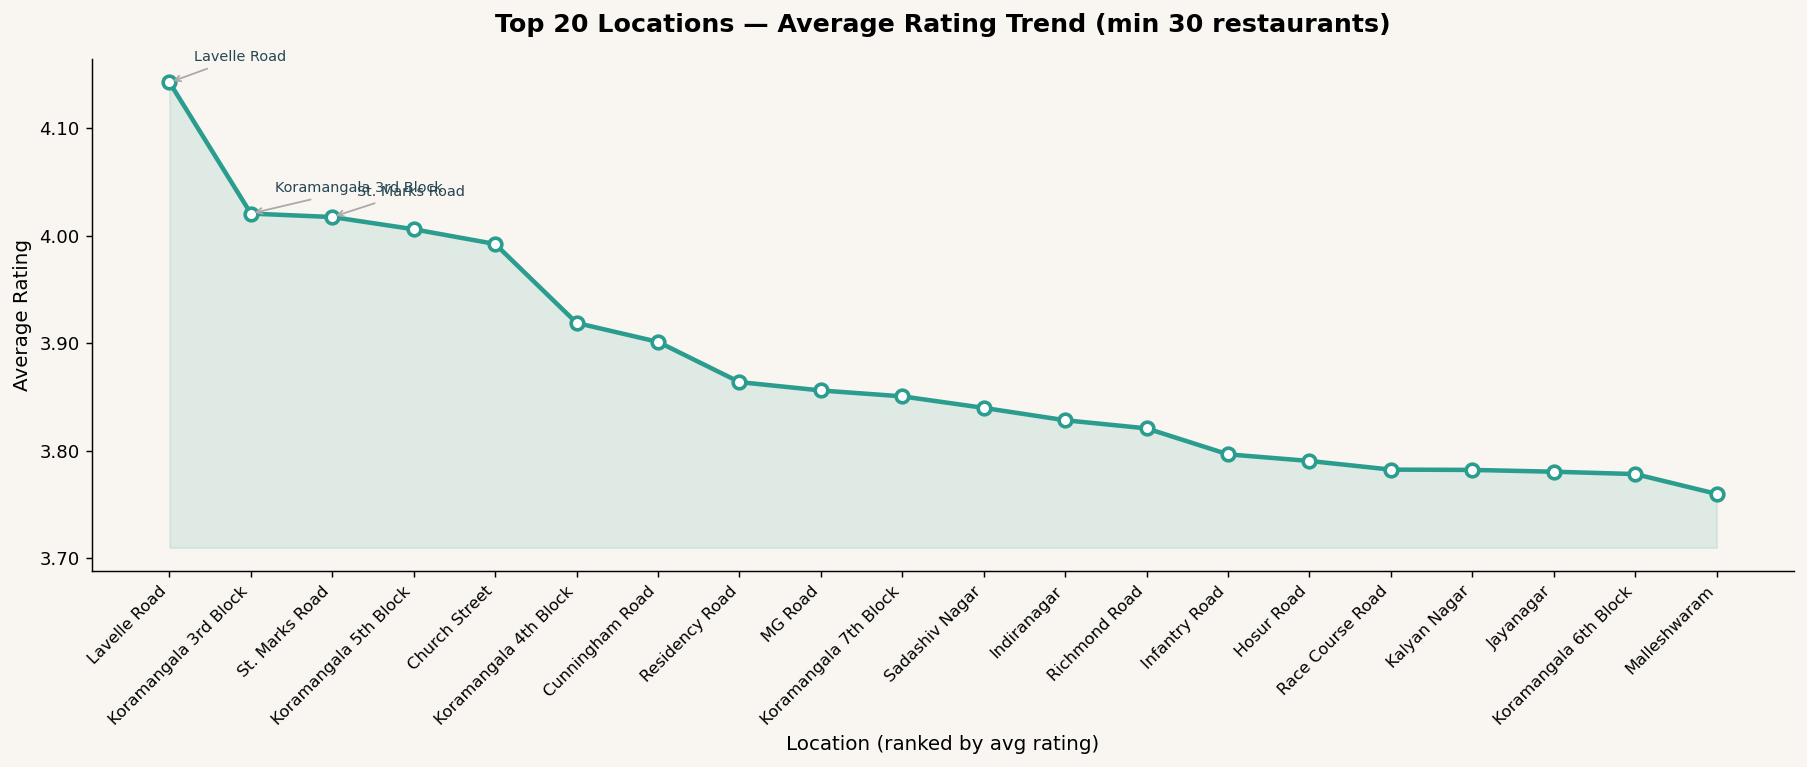

💡 Rating drops gradually across locations — even lower-ranked areas maintain respectable scores.


In [23]:
# Top 20 locations by restaurant count, ordered by avg rating
top20_locs = (
    df.groupby('location')
    .agg(avg_rating=('rate', 'mean'), count=('name', 'count'))
    .query('count >= 30')
    .sort_values('avg_rating', ascending=False)
    .head(20)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(top20_locs.index, top20_locs['avg_rating'],
        color=PALETTE[2], linewidth=2.5, marker='o', markersize=7,
        markerfacecolor='white', markeredgewidth=2, markeredgecolor=PALETTE[2])

ax.fill_between(top20_locs.index, top20_locs['avg_rating'],
                top20_locs['avg_rating'].min() - 0.05,
                alpha=0.12, color=PALETTE[2])

# Annotate top 3
for i in range(3):
    ax.annotate(top20_locs.loc[i, 'location'],
                xy=(i, top20_locs.loc[i, 'avg_rating']),
                xytext=(i + 0.3, top20_locs.loc[i, 'avg_rating'] + 0.02),
                fontsize=8, color='#264653',
                arrowprops=dict(arrowstyle='->', color='#aaa', lw=1))

ax.set_xticks(top20_locs.index)
ax.set_xticklabels(top20_locs['location'], rotation=45, ha='right', fontsize=9)
ax.set_title('Top 20 Locations — Average Rating Trend (min 30 restaurants)', pad=15)
ax.set_ylabel('Average Rating')
ax.set_xlabel('Location (ranked by avg rating)')
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))

fig.tight_layout()
plt.savefig('plot6_location_rating_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Rating drops gradually across locations — even lower-ranked areas maintain respectable scores.")

---
## 6️⃣ Key Takeaways & Conclusions

| # | Insight | Finding |
|---|---------|----------|
| 1 | **Online Ordering & Ratings** | Restaurants that accept online orders score higher on average — likely reflecting a more customer-centric approach |
| 2 | **Location Matters** | Certain localities consistently outperform others — a signal for restaurant entrepreneurs |
| 3 | **Price ≠ Quality (always)** | Premium restaurants tend to score higher, but mid-range outlets show the best value-to-rating ratio |
| 4 | **Cuisine Preferences** | North Indian & Chinese cuisines dominate — fast, affordable, and familiar |
| 5 | **Type Drives Strategy** | Quick Bites lead in count; Fine Dining leads in rating — different business models, different metrics |

---

### 🚀 Next Steps
- **Sentiment Analysis** on customer reviews using NLP
- **Geospatial mapping** of restaurant density across Bangalore
- **Predictive modelling** — can we predict a restaurant's rating from its features?
- **Time-series analysis** if order history data were available

---
*Notebook completed. All plots saved as `.png` files in the working directory.*